# MongoDB Query Benchmark

Ten queries against the Yelp aggregate collections, grouped as **simple filtering**,
**complex related-data queries** and **aggregated reports**. Each one is written out
plainly as `db.collection.find(...)` / `db.collection.aggregate(...)` and wrapped in
`bench(...)`, which records its **execution time**.

Per query:
- **`wall_ms_median`** - end-to-end wall-clock ms to run the query and fully
  materialize the results, median of `REPEATS` runs (after `WARMUP` warmups).
  This is the number to compare against an equivalent relational query.
- **`wall_ms_min` / `wall_ms_max`** - fastest and slowest of those same runs. The
  spread between them shows how stable the timing is; a wide gap usually means the
  cache was still filling up.
- **`n_returned`** - how many documents the query produced.

Heavy queries pass a smaller `repeats=` so the whole notebook still finishes in a
few minutes; the value used is visible in each cell and recorded in the results table.

Run the setup cells once, then run each query cell. Re-running a query cell
just updates its row (keyed by name), so timings never duplicate.

In [32]:
import os, time
from datetime import datetime, timezone
from statistics import median
import pandas as pd
from pymongo import MongoClient

MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
MONGO_DB  = os.getenv("MONGO_DB", "yelp")
REPEATS   = 10      # timed runs per query (median is reported)
WARMUP    = 1      # throwaway runs before timing (warms cache)

client = MongoClient(MONGO_URI)
db = client[MONGO_DB]
print("Connected:", MONGO_URI, "| db =", MONGO_DB)

Connected: mongodb://localhost:27017 | db = yelp


## Context - server, collection sizes, query constants

The queries below all target **Philadelphia** and the year **2018**, so those are
pinned here as constants and reused verbatim inside every query.

Note the document shape: the city lives at `location.city` (not at the top level), and
the per-business `review_count` / `stars` are the denormalized values stored on the
business aggregate.

In [33]:
print("server version:", client.server_info()["version"])
for c in ["businesses", "users", "reviews", "tips"]:
    print(f"  {c:12s}: {db[c].estimated_document_count():,}")

CITY = "Philadelphia"
YEAR_START = datetime(2018, 1, 1, tzinfo=timezone.utc)   # inclusive
YEAR_END   = datetime(2019, 1, 1, tzinfo=timezone.utc)   # exclusive

# busiest business, used by the profile point read in query 11
BID = db.businesses.find_one(sort=[("review_count", -1)], projection={"id": 1})["id"]

n_city = db.businesses.count_documents({"location.city": CITY})
print(f"\nCITY  : {CITY}  ({n_city:,} businesses)")
print(f"WINDOW: {YEAR_START:%Y-%m-%d} .. {YEAR_END:%Y-%m-%d} (exclusive)")
print(f"BID   : {BID}")

server version: 8.3.8
  businesses  : 150,346
  users       : 1,000,000
  reviews     : 1,999,994
  tips        : 754,776

CITY  : Philadelphia  (14,569 businesses)
WINDOW: 2018-01-01 .. 2019-01-01 (exclusive)
BID   : VQcCL9PiNL_wkGf-uF3fjg


## The timer

`bench(name, fn)` runs `fn()` (a lambda returning a cursor) `REPEATS` times, records the
median / min / max of those runs, and **returns the rows of the last run as a
`DataFrame`** - so a query cell that ends in `bench(...)` both records a timing and
displays its own output. Write the actual query in the lambda. Pass `repeats=` /
`warmup=` to make an expensive query cheaper to measure.

In [34]:
results = []

def bench(name, fn, repeats=REPEATS, warmups=WARMUP):
    """Time `fn` and return its result rows as a DataFrame (from the last timed run)."""
    times, rows = [], []

    for _ in range(warmups):
        rows = list(fn())

    for _ in range(repeats):
        t0 = time.perf_counter()
        rows = list(fn())
        times.append((time.perf_counter() - t0) * 1000.0)

    results[:] = [r for r in results if r["name"] != name]   # idempotent re-runs
    results.append({"db": "mongodb", "name": name,
                    "wall_ms_median": round(median(times), 2),
                    "wall_ms_min": round(min(times), 2),
                    "wall_ms_max": round(max(times), 2),
                    "n_returned": len(rows), "repeats": repeats})
    print(f"{name:32s}  wall={median(times):9.2f} ms  "
          f"(min {min(times):.2f} / max {max(times):.2f})  n={len(rows)}")
    return pd.DataFrame(rows)

# Simple filtering

Single-collection queries: a filter, a projection and at most a sort.

**1. Businesses in Philadelphia that are currently open and have more than 100 reviews**

`is_open` is stored as `1` / `0`; `review_count` is the denormalized total on the
business document, so no join is needed.

In [35]:
philly_open_over_100_reviews = bench("philly_open_over_100_reviews",
      lambda: db.businesses.find(
          {"location.city": CITY,
           "is_open": 1,
           "review_count": {"$gt": 100}},
          {"_id": 0, "id": 1, "name": 1, "stars": 1, "review_count": 1}
      ).sort([("review_count", -1)]))

philly_open_over_100_reviews      wall=   421.05 ms  (min 395.83 / max 442.46)  n=507


In [36]:
philly_open_over_100_reviews.head()

,id,name,stars,review_count
0,j-qtdD55OLfSqfsWuQTDJg,Parc,4.0,2884
1,ctHjyadbDQAtUFfkcAFEHw,Zahav,4.5,2846
2,RQAF6a0akMiot5lZZnMNNw,Dalessandro’s Steaks & Hoagies,4.0,2269
3,S8ZFYEgMejpChID8tzKo9A,Amada,4.0,2162
4,iUZEGx29miZObLd6_lt7Vg,Sabrina's Café,4.0,1760


**2. Five-star reviews written during 2018**

A range scan over `date` combined with an equality on `stars`. Only the identifying
fields are projected - pulling the full review text for every match would measure
network transfer more than query execution.

In [37]:
five_star_reviews_2018 = bench("five_star_reviews_2018",
      lambda: db.reviews.find(
          {"stars": 5,
           "date": {"$gte": YEAR_START, "$lt": YEAR_END}},
          {"_id": 0, "id": 1, "business_id": 1, "user_id": 1, "stars": 1, "date": 1}
      )
    )

five_star_reviews_2018            wall=  5168.93 ms  (min 4630.30 / max 5420.85)  n=135090


In [38]:
five_star_reviews_2018.head()

,id,business_id,user_id,stars,date
0,JBWZmBy69VMggxj3eYn17Q,kq5Ghhh14r-eCxlVmlyd8w,aFa96pz67TwOFu4Weq5Agg,5,2018-08-23 21:39:38
1,E9AB7V4z8xrt2uPF7T55FQ,Zx7n8mdt8OzLRXVzolXNhQ,iYY5Ii1LGpZCpXFkHlMefw,5,2018-04-27 23:03:21
2,4KpIldEM-tdnrJLqYzRfZQ,HTqXI5S2XcSlh_ylx9sE6g,Z5j9Xw_G0c7M2b1-iS67wg,5,2018-03-23 14:35:33
3,r1tPwFMILy0COeEQ-B3YLw,8xM8akbQhHDQdJO1sPMB1A,3M1_pyDSgMP6sRMz564eJw,5,2018-07-26 09:15:30
4,zcj7iTXdSz0GCBOReMTeiQ,Zx7n8mdt8OzLRXVzolXNhQ,X8XCFMZN8pFlWEZcKuKzZw,5,2018-01-21 17:12:47


**3. Businesses in Philadelphia that have a parking lot**

Yelp stores `BusinessParking` as a stringified dict
(`"{'garage': False, 'street': False, 'lot': True, ...}"`), so "has a parking lot"
is a regex on that attribute string.

In [39]:
philly_with_parking_lot = bench("philly_with_parking_lot",
      lambda: db.businesses.find(
          {"location.city": CITY,
           "attributes.BusinessParking": {"$regex": r"'lot':\s*True"}},
          {"_id": 0, "id": 1, "name": 1, "attributes.BusinessParking": 1}
      ))

philly_with_parking_lot           wall=   401.24 ms  (min 369.34 / max 652.90)  n=1565


In [40]:
philly_with_parking_lot.head()

,id,name,attributes
0,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,"{'BusinessParking': '{'garage': False, 'street..."
1,-4dYswJy7SPcbcERvitmIg,Pathmark,"{'BusinessParking': '{'garage': False, 'street..."
2,FTFtoylMzkrzqNVSl-bkKw,Giant Food Stores,"{'BusinessParking': '{u'valet': False, u'garag..."
3,jL_NufxqXi-BpW5uXKsPwQ,CVS Pharmacy,"{'BusinessParking': '{'garage': False, 'street..."
4,Tm3QiAVLJAR2fEJK7APPPQ,City Fitness - Northern Liberties,"{'BusinessParking': '{'garage': False, 'street..."


# Complex related-data queries

Queries that have to combine two or three collections with `$lookup`.

**4. Philadelphia restaurants whose most recent reviews mention brunch**

Full-text-ish search *inside* the embedded review array: keep restaurants where at least
one of the last 50 reviews is 4 stars or better and mentions "brunch", then return the
matching reviews together with the reviewers who wrote them.

The `$elemMatch` selects the businesses, and `$filter` re-runs the same predicate inside
the array to keep only the matching entries - the reviewer names come along for free
because they are stored on the preview. Relationally this is `reviews` joined to
`businesses` and `users`, an `ILIKE`, and a per-business top-N.

In [41]:
philly_brunch_mentions = bench("philly_brunch_mentions",
      lambda: db.businesses.aggregate([
          {"$match": {
              "location.city": CITY,
              "categories": "Restaurants",
              "reviews_preview": {"$elemMatch": {
                  "text": {"$regex": "brunch", "$options": "i"},
                  "stars": {"$gte": 4}}}}},
          {"$project": {
              "_id": 0, "name": 1, "stars": 1, "review_count": 1,
              "mentions": {"$filter": {
                  "input": "$reviews_preview", "as": "r",
                  "cond": {"$and": [
                      {"$gte": ["$$r.stars", 4]},
                      {"$regexMatch": {"input": "$$r.text", "regex": "brunch",
                                       "options": "i"}}]}}}}},
          {"$addFields": {"n_mentions": {"$size": "$mentions"},
                          "reviewers": "$mentions.user_name"}},
          {"$project": {"mentions": 0}},
          {"$sort": {"n_mentions": -1, "review_count": -1}},
          {"$limit": 25},
      ], allowDiskUse=True))

philly_brunch_mentions            wall=   568.19 ms  (min 530.58 / max 650.58)  n=25


In [42]:
philly_brunch_mentions.head()

,name,stars,review_count,n_mentions,reviewers
0,Winkel,4.5,179,19,"[Monique, Mike, Gwendolyn, Crystal, Lisa, Anna..."
1,More Sugar,4.5,65,19,"[Jeary, Jessica, Jason, Anna, Jimmy, Sandy, Ka..."
2,Ants Pants Café,4.0,554,18,"[Alex, Jessica, Lillian, Annie, Dom, Grace, Br..."
3,Lacroix Restaurant at The Rittenhouse,4.5,412,16,"[Bart, Kirstie, Connie, Katherine, Daniel, Mar..."
4,Winnie's Manayunk,3.5,615,15,"[Melissa, Lauren, Chika, Tish, Araba, Hilary, ..."


**5. Users who reviewed at least 3 different businesses in the same city**

Reviews carry no city, so every reviewed business has to be resolved to its city first.
Grouping the reviews per business before that join keeps it to one lookup per business
instead of one per review.

What comes out are `(user, city)` pairs covering 3+ distinct businesses - there are
~100k of them, so the pipeline sorts by breadth and keeps the top 100 **before**
joining the user documents; otherwise the query spends all its time fetching user
aggregates.

In [43]:
users_3plus_businesses_same_city = bench("users_3plus_businesses_same_city",
      lambda: db.reviews.aggregate([
          {"$group": {"_id": "$business_id", "users": {"$addToSet": "$user_id"}}},
          {"$lookup": {
              "from": "businesses",
              "localField": "_id", "foreignField": "id",
              "as": "biz",
              "pipeline": [{"$project": {"_id": 0, "name": 1,
                                         "city": "$location.city"}}]}},
          {"$unwind": "$biz"},
          {"$unwind": "$users"},
          {"$group": {"_id": {"user_id": "$users", "city": "$biz.city"},
                      "businesses": {"$addToSet": {"business_id": "$_id",
                                                   "name": "$biz.name"}}}},
          {"$match": {"$expr": {"$gte": [{"$size": "$businesses"}, 3]}}},
          {"$addFields": {"n_businesses": {"$size": "$businesses"}}},
          {"$sort": {"n_businesses": -1}},
          {"$limit": 100},
          {"$lookup": {
              "from": "users",
              "localField": "_id.user_id", "foreignField": "id",
              "as": "user",
              "pipeline": [{"$project": {"_id": 0, "id": 1, "name": 1, "fans": 1,
                                         "review_count": 1, "average_stars": 1}}]}},
          {"$unwind": "$user"},
          {"$project": {"_id": 0, "city": "$_id.city", "user": 1,
                        "n_businesses": 1, "businesses": 1}},
      ], allowDiskUse=True),
    )

users_3plus_businesses_same_city  wall= 91505.04 ms  (min 89556.52 / max 95679.78)  n=100


In [44]:
users_3plus_businesses_same_city.head()

,businesses,n_businesses,user,city
0,"[{'business_id': '_ZRynwYKBpUCMVHqR2vj4A', 'na...",326,"{'id': 'Xw7ZjaGfr0WNVt6s_5KZfA', 'name': 'Mari...",New Orleans
1,"[{'business_id': 'eFtQDmNER9pRB9YdPxMMXA', 'na...",322,"{'id': '0Igx-a1wAstiBDerGxXk2A', 'name': 'Jen'...",New Orleans
2,"[{'business_id': '5iUtqb6ONRcrnlBKic3g9A', 'na...",308,"{'id': '_BcWyKQL16ndpBdggh2kNA', 'name': 'Kare...",Philadelphia
3,"[{'business_id': 'RXY89AX0vz6gchV8T1r1Gg', 'na...",251,"{'id': '1HM81n6n4iPIFU5d2Lokhw', 'name': 'Shan...",New Orleans
4,"[{'business_id': 'xI2wOBEkYz7gtXxAV4v9MQ', 'na...",248,"{'id': 'wXdbkFZsfDR7utJvbWElyA', 'name': 'Ken'...",Indianapolis


**6. Business profile card - the whole page in one read**

Everything an application would render for a single business: the profile, its categories,
attributes and opening hours, the last 50 reviews *with the reviewer names already on
them*, the last 10 tips, and the check-in totals.

This is the query the aggregate model exists for. In PostgreSQL it is a five-way join
(`businesses`, `business_categories`, `categories`, `business_attributes`,
`business_hours`) plus two `LATERAL` top-N subqueries for the recent reviews and tips -
the review one joining `users` again for each author name - plus a `COUNT` over the
check-in partitions. Here it is a single indexed document fetch.

In [49]:
business_profile_card = bench("business_profile_card",
      lambda: db.businesses.find({"id": BID}))

business_profile_card             wall=     2.83 ms  (min 2.23 / max 4.91)  n=1


In [50]:
business_profile_card.head()

,_id,id,name,location,stars,is_open,attributes,categories,hours,review_count,tip_count,checkin_stats,checkin_monthly,reviews_preview,tips_preview
0,6aa05d57620a0dbf0922ab28,VQcCL9PiNL_wkGf-uF3fjg,Royal House,"{'address': '441 Royal St', 'city': 'New Orlea...",4.0,1,"{'WiFi': 'u'free'', 'Caters': 'False', 'Outdoo...","[American (New), Restaurants, Sandwiches, Seaf...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",4706,395,"{'total': 28927, 'first': 2010-02-12 23:15:48,...","[{'year': 2010, 'month': 2, 'count': 1}, {'yea...","[{'review_id': '1v-Xsiw3YYSRzC4GSlsekg', 'user...","[{'user_id': 'XyDS3rIqdSJ_k8p8jaxmtw', 'user_n..."


**7. Complimented tips on Philadelphia restaurants in 2018**

Tips filtered by the date window and `compliment_count >= 1`, then joined to the
business (kept only if it is a Philadelphia restaurant) and to the tip author.

In [47]:
complimented_tips_philly_2018 = bench("complimented_tips_philly_2018",
      lambda: db.tips.aggregate([
          {"$match": {"date": {"$gte": YEAR_START, "$lt": YEAR_END},
                      "compliment_count": {"$gte": 1}}},
          {"$lookup": {
              "from": "businesses",
              "localField": "business_id", "foreignField": "id",
              "as": "biz",
              "pipeline": [{"$match": {"location.city": CITY,
                                       "categories": "Restaurants"}},
                           {"$project": {"_id": 0, "name": 1}}]}},
          {"$unwind": "$biz"},          # drops tips whose business did not match
          {"$lookup": {
              "from": "users",
              "localField": "user_id", "foreignField": "id",
              "as": "author",
              "pipeline": [{"$project": {"_id": 0, "name": 1}}]}},
          {"$unwind": "$author"},
          {"$project": {"_id": 0,
                        "author": "$author.name",
                        "business": "$biz.name",
                        "text": 1, "compliment_count": 1, "date": 1}},
          {"$sort": {"compliment_count": -1, "date": 1}},
      ], allowDiskUse=True),
    )

complimented_tips_philly_2018     wall=  2175.90 ms  (min 2130.07 / max 2345.15)  n=65


In [48]:
complimented_tips_philly_2018.head()

,text,date,compliment_count,author,business
0,Seriously ... Close down this Taco Bell !,2018-02-21 18:09:52,2,Momo,Taco Bell
1,"Ardiente (Spanish for ""burning"")",2018-04-08 16:12:57,2,Chels,Ardiente
2,"If only I were hip to this joint sooner. Smh, ...",2018-04-15 03:51:12,2,Chels,South
3,Try the lunch specials,2018-09-05 16:16:25,2,Chris,Golden Triangle
4,Now Open! $1 donut special for opening day! On...,2018-10-05 13:51:35,2,Rachel,Federal Donuts


# Aggregated reports

Whole-collection roll-ups: group, average, rank.

**8. Elite vs non-elite users - engagement profile**

One `$group` over the whole `users` collection, splitting on `elite.is_elite` and averaging
fans, friends, useful votes and the eleven compliment counters. The compliments live in a
subdocument, so summing them is `$sum` over eleven sibling fields; relationally
`user_compliments` is a tall table with one row per user per compliment type, so the same
report needs a pivot and a join back to `users`.

In [45]:
elite_vs_rest_engagement = bench("elite_vs_rest_engagement",
      lambda: db.users.aggregate([
          {"$group": {
              "_id": "$elite.is_elite",
              "users": {"$sum": 1},
              "avg_fans": {"$avg": "$fans"},
              "avg_friends": {"$avg": "$friend_count"},
              "avg_reviews": {"$avg": "$review_count_total"},
              "avg_useful_votes": {"$avg": "$votes.useful"},
              "avg_compliments": {"$avg": {"$sum": [
                  "$compliments.hot", "$compliments.more", "$compliments.profile",
                  "$compliments.cute", "$compliments.list", "$compliments.note",
                  "$compliments.plain", "$compliments.cool", "$compliments.funny",
                  "$compliments.writer", "$compliments.photos"]}}}},
          {"$project": {
              "_id": 0, "is_elite": "$_id", "users": 1,
              "avg_fans": {"$round": ["$avg_fans", 2]},
              "avg_friends": {"$round": ["$avg_friends", 2]},
              "avg_reviews": {"$round": ["$avg_reviews", 2]},
              "avg_useful_votes": {"$round": ["$avg_useful_votes", 2]},
              "avg_compliments": {"$round": ["$avg_compliments", 2]}}},
          {"$sort": {"is_elite": -1}},
      ], allowDiskUse=True)
    )

elite_vs_rest_engagement          wall= 17026.01 ms  (min 16548.46 / max 18283.49)  n=2


In [46]:
elite_vs_rest_engagement.head()

,users,is_elite,avg_fans,avg_friends,avg_reviews,avg_useful_votes,avg_compliments
0,68463,True,25.71,239.57,244.11,727.87,320.72
1,931537,False,0.52,46.22,17.31,16.72,2.63


**9. Average number of check-ins per business, for each category**

`checkin_stats.total` is precomputed on the business aggregate, so this is a single
`$unwind` + `$group`. Businesses with no check-ins count as 0 rather than being
skipped, so the average really is per business in the category.

In [51]:
category_avg_checkins_per_business = bench("category_avg_checkins_per_business",
      lambda: db.businesses.aggregate([
          {"$unwind": "$categories"},
          {"$group": {"_id": "$categories",
                      "businesses": {"$sum": 1},
                      "avg_checkins": {"$avg": {"$ifNull": ["$checkin_stats.total", 0]}}}},
          {"$project": {"_id": 0, "category": "$_id", "businesses": 1,
                        "avg_checkins": {"$round": ["$avg_checkins", 2]}}},
          {"$sort": {"avg_checkins": -1}},
      ], allowDiskUse=True))

category_avg_checkins_per_business  wall=  2050.98 ms  (min 1812.01 / max 2410.80)  n=1311


In [52]:
category_avg_checkins_per_business.head()

,businesses,category,avg_checkins
0,1,Conveyor Belt Sushi,2428.00
1,122,Airports,2147.42
2,2,Israeli,1677.50
3,1,Pickleball,1474.00
4,23,Public Markets,1240.30


**10. Top 5 businesses per city by average rating (at least 50 reviews)**

`stars` on the business document *is* its average rating, so the ranking is a sort
followed by a per-city `$push` + `$slice` - MongoDB's equivalent of a windowed
`ROW_NUMBER() <= 5`. Ties are broken by review count.

In [53]:
top5_per_city_min_50_reviews = bench("top5_per_city_min_50_reviews",
      lambda: db.businesses.aggregate([
          {"$match": {"review_count": {"$gte": 50}}},
          {"$sort": {"stars": -1, "review_count": -1}},
          {"$group": {"_id": "$location.city",
                      "ranked": {"$push": {"business_id": "$id", "name": "$name",
                                           "stars": "$stars",
                                           "review_count": "$review_count"}}}},
          {"$project": {"_id": 0, "city": "$_id",
                        "top_5": {"$slice": ["$ranked", 5]}}},
          {"$sort": {"city": 1}},
      ], allowDiskUse=True))

top5_per_city_min_50_reviews      wall=   537.26 ms  (min 509.77 / max 593.55)  n=449


In [54]:
top5_per_city_min_50_reviews.head()

,city,top_5
0,Abington,"[{'business_id': 'lVirNKheM7Ps8eVRt0IyOg', 'na..."
1,Abington Township,"[{'business_id': 'bFln2Z17KfFIcEz4TRaHjw', 'na..."
2,Affton,"[{'business_id': 'faReoVCPuY0XUE3CSIVsAg', 'na..."
3,Aldan,"[{'business_id': 'auBRFCUG20A_-4Mxot0dgQ', 'na..."
4,Alton,"[{'business_id': '46fEorqn2nVbxdclHdHdKg', 'na..."


## Results - table, CSV, chart

saved -> benchmarks/mongo_query_times.csv
plot skipped: [Errno 2] No such file or directory: 'C:\\Projects\\NBP_Proekt\\data\\benchmarks\\mongo_query_times.png'


,db,name,wall_ms_median,wall_ms_min,wall_ms_max,n_returned,repeats
0,mongodb,philly_open_over_100_reviews,421.05,395.83,442.46,507,10
1,mongodb,five_star_reviews_2018,5168.93,4630.30,5420.85,135090,10
2,mongodb,philly_with_parking_lot,401.24,369.34,652.90,1565,10
3,mongodb,philly_brunch_mentions,568.19,530.58,650.58,25,10
4,mongodb,users_3plus_businesses_same_city,91505.04,89556.52,95679.78,100,10
5,mongodb,elite_vs_rest_engagement,17026.01,16548.46,18283.49,2,10
6,mongodb,complimented_tips_philly_2018,2175.90,2130.07,2345.15,65,10
7,mongodb,business_profile_card,2.83,2.23,4.91,1,10
8,mongodb,category_avg_checkins_per_business,2050.98,1812.01,2410.80,1311,10
9,mongodb,top5_per_city_min_50_reviews,537.26,509.77,593.55,449,10


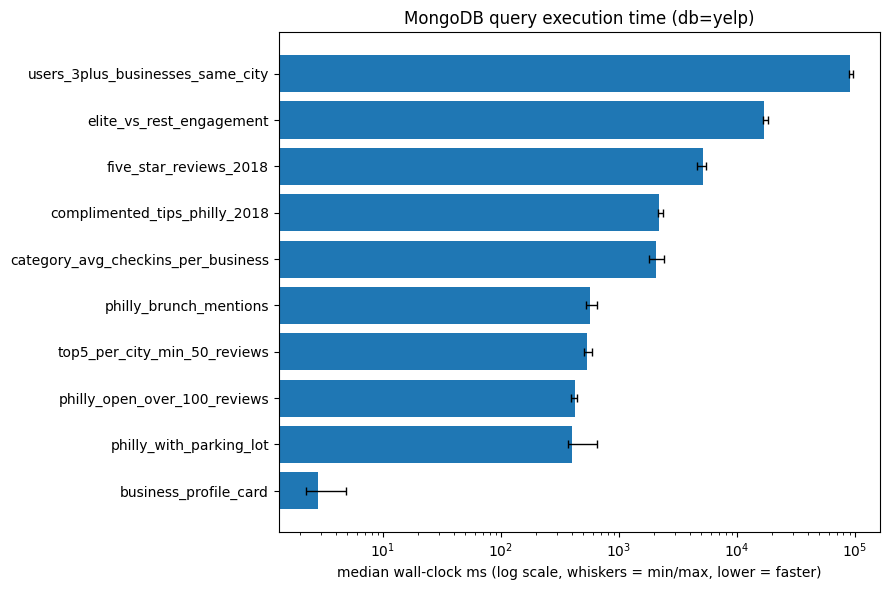

In [55]:
results_df = pd.DataFrame(results)
os.makedirs("benchmarks", exist_ok=True)
results_df.to_csv("benchmarks/mongo_query_times.csv", index=False)
print("saved -> benchmarks/mongo_query_times.csv")

try:
    import matplotlib.pyplot as plt
    d = results_df.dropna(subset=["wall_ms_median"]).sort_values("wall_ms_median")
    # asymmetric whiskers: median back to min, median out to max
    err = [(d["wall_ms_median"] - d["wall_ms_min"]).clip(lower=0),
           (d["wall_ms_max"] - d["wall_ms_median"]).clip(lower=0)]
    plt.figure(figsize=(9, 6))
    plt.barh(d["name"], d["wall_ms_median"], xerr=err, capsize=3,
             error_kw={"elinewidth": 1, "ecolor": "black"})
    plt.xscale("log")
    plt.xlabel("median wall-clock ms (log scale, whiskers = min/max, lower = faster)")
    plt.title(f"MongoDB query execution time (db={MONGO_DB})")
    plt.tight_layout()
    plt.savefig("data/benchmarks/mongo_query_times.png", dpi=120)
    plt.show()
except Exception as e:
    print("plot skipped:", e)

results_df